# 🩺 Dermatological Image Classification


## 1. Imports

In [1]:
import os
import random
import math
import time
import json
import warnings
from pathlib import Path
from collections import Counter
from copy import deepcopy

warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, roc_auc_score, top_k_accuracy_score
)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR, ReduceLROnPlateau

import torchvision.transforms as T
from torchvision.models import efficientnet_b1, EfficientNet_B1_Weights
from torchvision.datasets import ImageFolder

import albumentations as A
from albumentations.pytorch import ToTensorV2
from PIL import Image
import cv2

SEED = 42
def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print(f'Torch version: {torch.__version__}')

Device: cuda
Torch version: 2.10.0+cu128


## 2. Dataset Quality Check

In [2]:
from glob import glob
from tqdm import tqdm
from shutil import copy2

DATA_DIR = "/kaggle/input/datasets/vedharshav/skindiseasedataset/train"

def check_image(img_path):
    try:
        img = cv2.imread(img_path)
        if img is None:
            return "corrupt"
        h, w, c = img.shape
        if h < 100 or w < 100:
            return "small"
        mean_val = img.mean()
        if mean_val < 30 or mean_val > 220:
            return "suspicious"
        if img.std() < 10:
            return "suspicious"
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        edges = cv2.Canny(gray, 100, 200)
        if edges.mean() > 25:
            return "suspicious"
        return "ok"
    except:
        return "corrupt"

image_paths = []
for ext in ["jpg", "jpeg", "png", "JPG", "JPEG", "PNG"]:
    image_paths.extend(glob(f"{DATA_DIR}/**/*.{ext}", recursive=True))

print(f"Total images found: {len(image_paths)}")

corrupt_images, small_images, suspicious_images = [], [], []
for path in tqdm(image_paths):
    result = check_image(path)
    if result == "corrupt":   corrupt_images.append(path)
    elif result == "small":   small_images.append(path)
    elif result == "suspicious": suspicious_images.append(path)

print(f"\n📊 DATASET REPORT")
print(f"Corrupt  : {len(corrupt_images)}")
print(f"Too small: {len(small_images)}")
print(f"Suspicious: {len(suspicious_images)}")

Total images found: 15809


100%|██████████| 15809/15809 [04:08<00:00, 63.70it/s] 


📊 DATASET REPORT
Corrupt  : 0
Too small: 3
Suspicious: 3469


In [3]:
SRC_DIR = DATA_DIR
DST_DIR = "/kaggle/working/clean_dataset"
os.makedirs(DST_DIR, exist_ok=True)

removed, kept = 0, 0
image_paths = []
for ext in ["jpg", "jpeg", "png", "JPG", "JPEG", "PNG"]:
    image_paths += glob(f"{SRC_DIR}/**/*.{ext}", recursive=True)

for path in tqdm(image_paths):
    img = cv2.imread(path)
    if img is None:
        removed += 1; continue
    if img.mean() < 25 or img.mean() > 230:
        removed += 1; continue
    if img.std() < 8:
        removed += 1; continue
    rel_path  = os.path.relpath(path, SRC_DIR)
    save_path = os.path.join(DST_DIR, rel_path)
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    copy2(path, save_path)
    kept += 1

print(f"✅ Kept: {kept}  |  ❌ Removed: {removed}")

100%|██████████| 15809/15809 [03:09<00:00, 83.48it/s] 

✅ Kept: 15799  |  ❌ Removed: 10


## 3. Configuration

In [4]:
class CFG:
    # ── Paths ──────────────────────────────────────────────────────────────────
    DATA_DIR        = '/kaggle/working/clean_dataset'
    OUTPUT_DIR      = '/kaggle/working/'
    CHECKPOINT_PATH = '/kaggle/working/best_model.pth'

    # ── Dataset ────────────────────────────────────────────────────────────────
    VAL_SIZE        = 0.15
    NUM_WORKERS     = 4

    # ── Progressive Resizing ───────────────────────────────────────────────────
    IMG_SIZE_STAGE1 = 224           # Phase 1: frozen backbone
    IMG_SIZE_STAGE2 = 240           # Phase 2: unfreeze + fine-tune

    # ── Training ───────────────────────────────────────────────────────────────
    BATCH_SIZE      = 64            # Single GPU — no sampler conflict
    EPOCHS_STAGE1   = 12            # Head-only training
    EPOCHS_STAGE2   = 30            # Full fine-tune
    LR_HEAD         = 3e-3          # High LR for randomly-init head
    LR_FINETUNE     = 1e-4          # Low LR for fine-tuning backbone
    WEIGHT_DECAY    = 1e-4
    GRAD_CLIP       = 1.0
    EARLY_STOP      = 7             # Patience epochs
    EARLY_STOP_S2     = 12  
    # ── Loss ───────────────────────────────────────────────────────────────────
    # Stage 1
    FOCAL_GAMMA = 1.5
    FOCAL_ALPHA = 1.0
    
    # Stage 2
    FOCAL_GAMMA_S2 = 2.0
    FOCAL_ALPHA_S2 = 1.0
 
    TRIPLET_MARGIN  = 0.3
    TRIPLET_WEIGHT_S1 = 0.0         # Stage 1: focal only (backbone frozen = bad embeddings)
    TRIPLET_WEIGHT_S2 = 0.05         # Stage 2: focal + triplet (backbone unfrozen)
    EMBEDDING_DIM   = 128

    # ── OOD ────────────────────────────────────────────────────────────────────
    MC_DROPOUT_PASSES  = 20
    OOD_CONF_THRESHOLD = 0.30
    OOD_VAR_THRESHOLD  = 0.05

    # ── TTA ────────────────────────────────────────────────────────────────────
    TTA_STEPS       = 7

    # ── CutMix / MixUp ─────────────────────────────────────────────────────────
    CUTMIX_PROB     = 0.2           # 20% cutmix
    MIXUP_PROB      = 0.2           # 20% mixup  — remaining 60% is clean batches
    MIXUP_ALPHA     = 0.4           # blend strength

    # ── Misc ───────────────────────────────────────────────────────────────────
    USE_AMP         = True
    TOP_K           = [3, 5]

Path(CFG.OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
print('Config loaded ✓')

Config loaded ✓


## 4. Data Loading & Stratified Split

In [5]:
def build_file_list(root: str):
    """Returns (paths, labels, class_names) from ImageFolder structure."""
    dataset = ImageFolder(root)
    paths   = [s[0] for s in dataset.samples]
    labels  = [s[1] for s in dataset.samples]
    classes = dataset.classes
    return paths, labels, classes

all_paths, all_labels, CLASS_NAMES = build_file_list(CFG.DATA_DIR)
NUM_CLASSES = len(CLASS_NAMES)

print(f'Total images : {len(all_paths)}')
print(f'Num classes  : {NUM_CLASSES}')
print(f'Classes      : {CLASS_NAMES}')

counts = Counter(all_labels)
print('\nClass counts:')
for idx, name in enumerate(CLASS_NAMES):
    print(f'  [{idx:2d}] {name}: {counts[idx]}')

# Stratified split
sss = StratifiedShuffleSplit(n_splits=1, test_size=CFG.VAL_SIZE, random_state=SEED)
train_idx, val_idx = next(sss.split(all_paths, all_labels))

train_paths  = [all_paths[i]  for i in train_idx]
train_labels = [all_labels[i] for i in train_idx]
val_paths    = [all_paths[i]  for i in val_idx]
val_labels   = [all_labels[i] for i in val_idx]

print(f'\nTrain: {len(train_paths)} | Val: {len(val_paths)}')
weak_classes = [25, 26, 29, 16]

Total images : 15799
Num classes  : 32
Classes      : ['Acne', 'Basal Cell Carcinoma', 'Benign tumors', 'Bullous', 'Candidiasis', 'Dermatofibroma', 'DrugEruption', 'Eczema', 'Hailey-Hailey Disease', 'Herpes Simplex', 'Impetigo', 'Infestations Bites', 'Keratosis', 'Larva Migrans', 'Leprosy', 'Lichen Disorder', 'Lupus Erythematosus', 'Melanoma', 'Moles', 'Molluscum Contagiosum', 'Nevus', 'Normal', 'Pityriasis Rosea', 'Psoriasis', 'Rosacea', 'Squamous cell carcinoma', 'Sun Sunlight Damage', 'Tinea', 'Vascular Tumors or Lesion', 'Vasculitis', 'Vitiligo', 'Warts']

Class counts:
  [ 0] Acne: 593
  [ 1] Basal Cell Carcinoma: 710
  [ 2] Benign tumors: 1088
  [ 3] Bullous: 580
  [ 4] Candidiasis: 248
  [ 5] Dermatofibroma: 88
  [ 6] DrugEruption: 547
  [ 7] Eczema: 1010
  [ 8] Hailey-Hailey Disease: 116
  [ 9] Herpes Simplex: 88
  [10] Impetigo: 105
  [11] Infestations Bites: 524
  [12] Keratosis: 651
  [13] Larva Migrans: 112
  [14] Leprosy: 515
  [15] Lichen Disorder: 658
  [16] Lupus Erythe

## 5. Augmentation Pipeline

In [6]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

def get_train_transforms(img_size: int) -> A.Compose:
    """Dermatology-optimised train transforms — preserves lesion texture."""
    return A.Compose([
        A.RandomResizedCrop(
            size=(img_size, img_size),
            scale=(0.9, 1.0),
            ratio=(0.95, 1.05),
            interpolation=cv2.INTER_LINEAR,
            p=1.0
        ),
        A.HorizontalFlip(p=0.5),
        A.Rotate(limit=10, border_mode=cv2.BORDER_REFLECT_101, p=0.3),
        A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.5),
        A.HueSaturationValue(hue_shift_limit=5, sat_shift_limit=10, val_shift_limit=10, p=0.3),
        A.GaussNoise(var_limit=(5.0, 15.0), p=0.1),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2(),
    ])

def get_val_transforms(img_size: int) -> A.Compose:
    """Deterministic val transforms — no augmentation."""
    return A.Compose([
        A.Resize(int(img_size * 1.1), int(img_size * 1.1)),
        A.CenterCrop(img_size, img_size),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2(),
    ])

def get_tta_transform(img_size: int) -> A.Compose:
    """Lightweight TTA transform."""
    return A.Compose([
        A.Resize(img_size, img_size),
        A.HorizontalFlip(p=0.5),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2(),
    ])

def stronger_augmentation(img):
    aug = A.Compose([
        A.RandomBrightnessContrast(brightness_limit=0.4,
                                   contrast_limit=0.4,
                                   p=1.0),
        A.ColorJitter(brightness=0.4,
                      contrast=0.4,
                      saturation=0.3,
                      hue=0.1,
                      p=1.0),
    ])
    return aug(image=img)['image']

print('Transforms defined ✓')

Transforms defined ✓


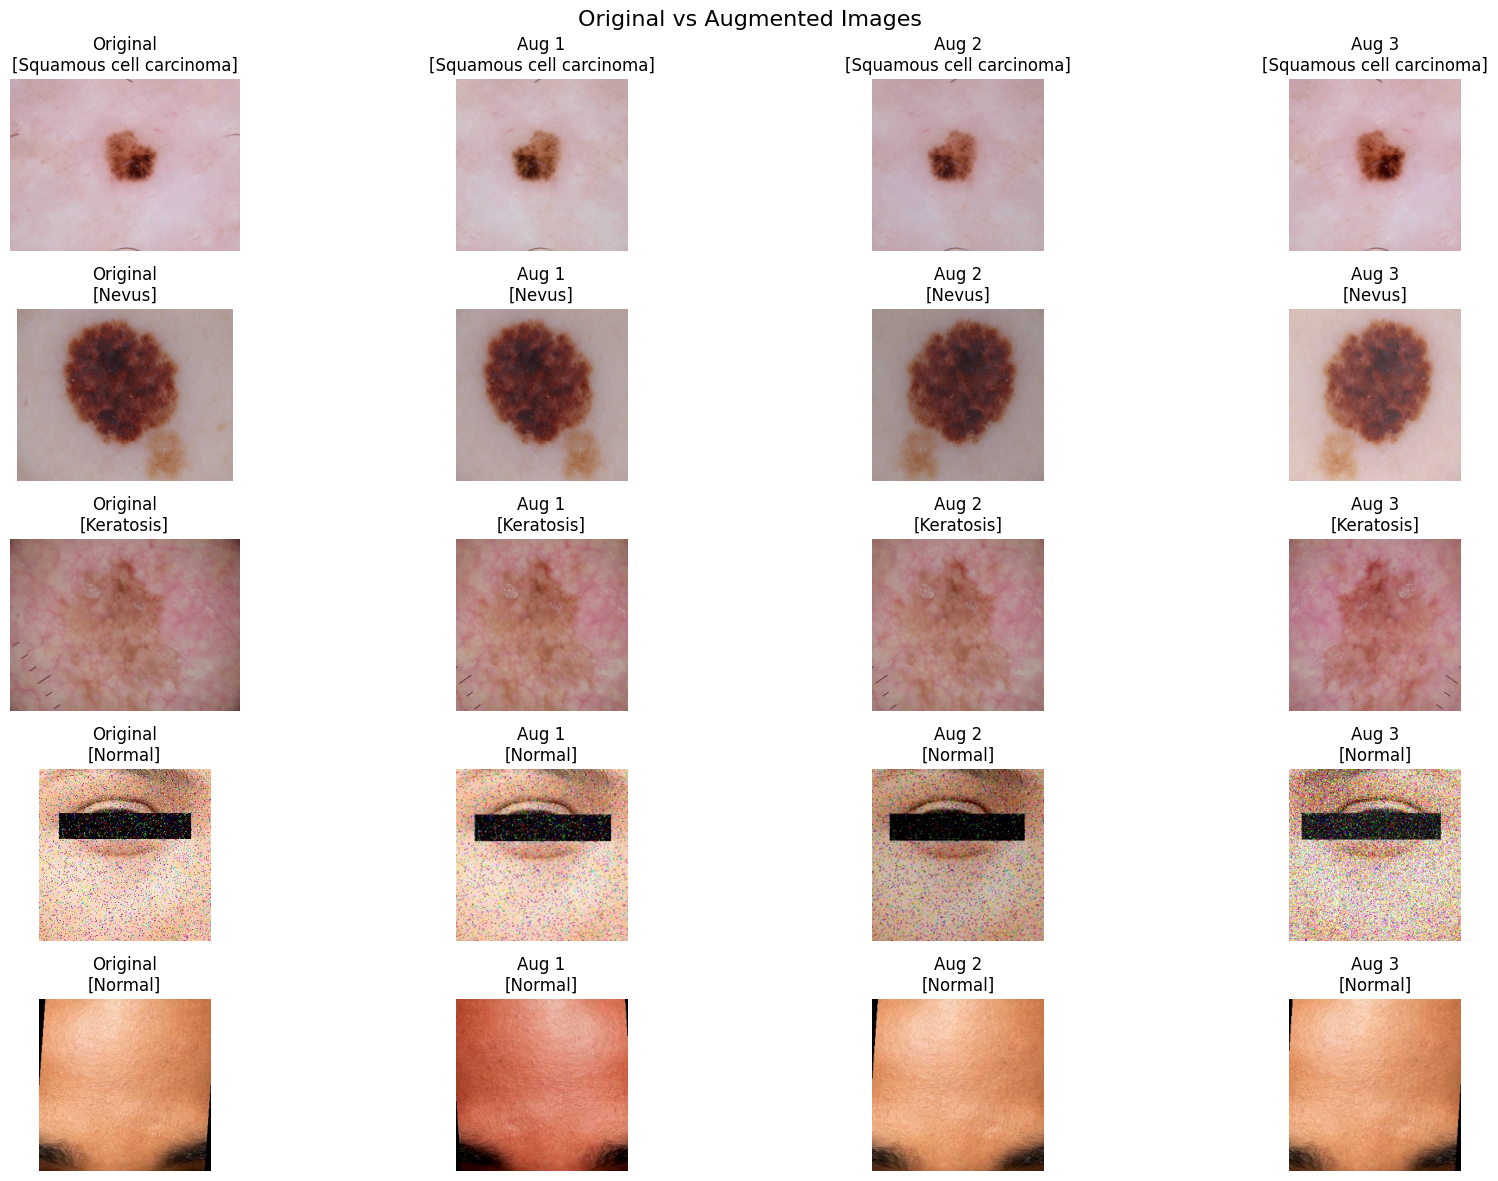

In [7]:
from glob import glob as _glob

def denormalize(img):
    img = img.transpose(1, 2, 0)
    mean = np.array(IMAGENET_MEAN)
    std  = np.array(IMAGENET_STD)
    return np.clip(img * std + mean, 0, 1)

image_paths_viz = _glob(f"{CFG.DATA_DIR}/**/*.jpg", recursive=True)
image_paths_viz = random.sample(image_paths_viz, min(5, len(image_paths_viz)))
transform_viz   = get_train_transforms(CFG.IMG_SIZE_STAGE1)

plt.figure(figsize=(18, 12))
for i, img_path in enumerate(image_paths_viz):
    class_name = os.path.basename(os.path.dirname(img_path))
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)

    plt.subplot(5, 4, i*4 + 1)
    plt.imshow(img); plt.title(f"Original\n[{class_name}]"); plt.axis('off')

    for j in range(3):
        aug_img = denormalize(transform_viz(image=img)['image'].cpu().numpy())
        plt.subplot(5, 4, i*4 + j + 2)
        plt.imshow(aug_img); plt.title(f"Aug {j+1}\n[{class_name}]"); plt.axis('off')

plt.suptitle("Original vs Augmented Images", fontsize=16)
plt.tight_layout(); plt.show()

## 6. Dataset & DataLoader

In [8]:
class DermaDataset(Dataset):
    def __init__(self, paths, labels, transform=None, apply_clahe=False):
        self.paths       = paths
        self.labels      = labels
        self.transform   = transform
        self.apply_clahe = apply_clahe

    def __len__(self):
        return len(self.paths)

    def _load_image(self, path: str) -> np.ndarray:
        img = cv2.imread(path)
        if img is None:
            raise FileNotFoundError(f"Cannot read: {path}")
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        if self.apply_clahe:
            lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
            clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
            lab[:, :, 0] = clahe.apply(lab[:, :, 0])
            img = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
        return img

    def __getitem__(self, idx):
        img   = self._load_image(self.paths[idx])
        label = self.labels[idx]
        if label in weak_classes and random.random() < 0.3:
            img = stronger_augmentation(img)
        if self.transform:
            img = self.transform(image=img)['image']
        return img, label


def build_loaders(img_size: int, batch_size: int, apply_clahe: bool = False): 
    """ Build train/val DataLoaders. 
    NOTE: No WeightedRandomSampler — FocalLoss with class_weights handles imbalance.
    Using both sampler + FocalLoss over-corrects and collapses training. """ 
    train_ds = DermaDataset(train_paths, train_labels, transform=get_train_transforms(img_size), apply_clahe=apply_clahe) 
    val_ds = DermaDataset(val_paths, val_labels, transform=get_val_transforms(img_size), apply_clahe=apply_clahe)
    train_dl = DataLoader(train_ds, batch_size=batch_size,
                          shuffle=True,
                          num_workers=CFG.NUM_WORKERS,
                          pin_memory=True,
                          drop_last=True)
    val_dl   = DataLoader(val_ds, batch_size=batch_size,
                          shuffle=False,
                          num_workers=CFG.NUM_WORKERS,
                          pin_memory=True)
    return train_dl, val_dl

print('Dataset classes defined ✓')

Dataset classes defined ✓


## 7. Model Definition

In [9]:
class DermaNet(nn.Module):
    """
    EfficientNet-B1 backbone with:
    - Embedding head (for Triplet Loss in Stage 2)
    - Classification head
    - MC Dropout support for OOD detection
    """
    def __init__(self, num_classes: int, embedding_dim: int = 128,
                 dropout_rate: float = 0.4):
        super().__init__()
        weights  = EfficientNet_B1_Weights.IMAGENET1K_V1
        backbone = efficientnet_b1(weights=weights)
        in_feats = backbone.classifier[1].in_features

        self.features = backbone.features
        self.avgpool  = backbone.avgpool

        self.embedding_head = nn.Sequential(
            nn.Dropout(p=dropout_rate),
            nn.Linear(in_feats, embedding_dim),
            nn.BatchNorm1d(embedding_dim),
            nn.ReLU(inplace=True),
        )
        self.classifier = nn.Sequential(
            nn.Dropout(p=dropout_rate),
            nn.Linear(embedding_dim, num_classes),
        )
        self._freeze_backbone()

    def _freeze_backbone(self):
        for p in self.features.parameters():
            p.requires_grad = False
        print('Backbone frozen ✓')

    def unfreeze_top_n_blocks(self, n: int = 3):
        """Unfreeze last n MBConv blocks."""
        blocks = list(self.features.children())
        for block in blocks[-n:]:
            for p in block.parameters():
                p.requires_grad = True
        print(f'Unfroze top {n} backbone blocks ✓')

    def unfreeze_all(self):
        for p in self.features.parameters():
            p.requires_grad = True
        print('Full backbone unfrozen ✓')

    def forward(self, x, return_embedding: bool = False):
        x      = self.features(x)
        x      = self.avgpool(x)
        x      = x.flatten(1)
        emb    = self.embedding_head(x)
        logits = self.classifier(emb)
        if return_embedding:
            return logits, emb
        return logits


def build_model(num_classes: int) -> nn.Module:
    model     = DermaNet(num_classes, embedding_dim=CFG.EMBEDDING_DIM, dropout_rate=0.4)
    model     = model.to(DEVICE)
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'Total params: {total/1e6:.2f}M | Trainable: {trainable/1e6:.2f}M')
    return model

print('Model class defined ✓')

Model class defined ✓


## 8. Loss Functions

In [10]:
def compute_class_weights(labels, num_classes: int) -> torch.Tensor:
    counts  = Counter(labels)
    total   = len(labels)
    weights = torch.tensor(
        [total / (num_classes * counts.get(i, 1)) for i in range(num_classes)],
        dtype=torch.float32
    )
    return weights


class FocalLoss(nn.Module):
    """Multi-class Focal Loss with optional per-class weights."""
    def __init__(self, gamma: float = 1.0, alpha: float = 1.0,
                 weight: torch.Tensor = None):
        super().__init__()
        self.gamma  = gamma
        self.alpha  = alpha
        self.weight = weight

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        ce_loss = F.cross_entropy(logits, targets, weight=self.weight, reduction='none')
        pt      = torch.exp(-ce_loss)
        focal   = self.alpha * (1 - pt) ** self.gamma * ce_loss
        return focal.mean()


class TripletLoss(nn.Module):
    """Online hard Triplet Loss (batch hard mining)."""
    def __init__(self, margin: float = 0.3):
        super().__init__()
        self.margin = margin

    def forward(self, embeddings: torch.Tensor, labels: torch.Tensor) -> torch.Tensor:
        device = embeddings.device
        dot   = torch.mm(embeddings, embeddings.t())
        sq    = dot.diag().unsqueeze(1).expand_as(dot)
        dist  = (sq + sq.t() - 2 * dot).clamp(min=0).sqrt()

        n = labels.size(0)
        total_loss = torch.tensor(0.0, device=device)
        valid = 0

        for i in range(n):
            pos_mask = (labels == labels[i]).float()
            neg_mask = (labels != labels[i]).float()
            pos_mask[i] = 0

            if pos_mask.sum() == 0 or neg_mask.sum() == 0:
                continue

            hardest_pos = (dist[i] * pos_mask).max()
            hardest_neg = (dist[i] + 1e9 * (1 - neg_mask)).min()
            loss_i      = F.relu(hardest_pos - hardest_neg + self.margin)
            total_loss += loss_i
            valid      += 1

        return total_loss / max(valid, 1)


class CombinedLoss(nn.Module):
    """Focal Loss + optional Triplet Loss.
    
    triplet_weight=0.0 → pure Focal (Stage 1, backbone frozen)
    triplet_weight=0.4 → Focal + Triplet (Stage 2, backbone unfrozen)
    """
    def __init__(self, class_weights: torch.Tensor, triplet_weight: float = 0.0):
        super().__init__()
        self.focal_loss   = FocalLoss(gamma=CFG.FOCAL_GAMMA,
                                       alpha=CFG.FOCAL_ALPHA,
                                       weight=class_weights.to(DEVICE))
        self.triplet_loss = TripletLoss(margin=CFG.TRIPLET_MARGIN)
        self.tw           = triplet_weight

    def forward(self, logits, embeddings, targets):
        focal = self.focal_loss(logits, targets)
        # Short-circuit: skip O(n²) triplet computation when weight=0
        if self.tw == 0.0:
            return focal, focal.item(), 0.0
        triplet = self.triplet_loss(embeddings, targets)
        return focal + self.tw * triplet, focal.item(), triplet.item()


print('Loss functions defined ✓')

Loss functions defined ✓


In [11]:
# Compute class weights
class_weights = compute_class_weights(train_labels, NUM_CLASSES)

print("Class Weights:\n")
for i, w in enumerate(class_weights):
    print(f"Class {i}: {w.item():.4f}")

print("\nTensor format:")
print(class_weights)

Class Weights:

Class 0: 0.8327
Class 1: 0.6959
Class 2: 0.4537
Class 3: 0.8512
Class 4: 1.9889
Class 5: 5.5954
Class 6: 0.9025
Class 7: 0.4891
Class 8: 4.2390
Class 9: 5.5954
Class 10: 4.7152
Class 11: 0.9430
Class 12: 0.7589
Class 13: 4.4174
Class 14: 0.9581
Class 15: 0.7507
Class 16: 1.2235
Class 17: 0.9183
Class 18: 1.3670
Class 19: 4.6116
Class 20: 1.6587
Class 21: 0.3688
Class 22: 4.7688
Class 23: 0.5339
Class 24: 1.9429
Class 25: 2.5129
Class 26: 1.5836
Class 27: 0.5353
Class 28: 0.7521
Class 29: 1.0706
Class 30: 0.6936
Class 31: 0.8530

Tensor format:
tensor([0.8327, 0.6959, 0.4537, 0.8512, 1.9889, 5.5954, 0.9025, 0.4891, 4.2390,
        5.5954, 4.7152, 0.9430, 0.7589, 4.4174, 0.9581, 0.7507, 1.2235, 0.9183,
        1.3670, 4.6116, 1.6587, 0.3688, 4.7688, 0.5339, 1.9429, 2.5129, 1.5836,
        0.5353, 0.7521, 1.0706, 0.6936, 0.8530])


## 9. CutMix & MixUp Helpers

In [12]:
def cutmix_data(x, y, alpha=1.0):
    lam      = np.random.beta(alpha, alpha)
    rand_idx = torch.randperm(x.size(0), device=x.device)
    y_a, y_b = y, y[rand_idx]

    _, _, H, W = x.shape
    cut_rat = np.sqrt(1.0 - lam)
    cut_w, cut_h = int(W * cut_rat), int(H * cut_rat)
    cx, cy = np.random.randint(W), np.random.randint(H)
    bbx1 = np.clip(cx - cut_w // 2, 0, W)
    bby1 = np.clip(cy - cut_h // 2, 0, H)
    bbx2 = np.clip(cx + cut_w // 2, 0, W)
    bby2 = np.clip(cy + cut_h // 2, 0, H)

    x = x.clone()
    x[:, :, bby1:bby2, bbx1:bbx2] = x[rand_idx, :, bby1:bby2, bbx1:bbx2]
    lam = 1 - (bbx2 - bbx1) * (bby2 - bby1) / (W * H)
    return x, y_a, y_b, lam


def mixup_data(x, y, alpha=0.4):
    lam      = np.random.beta(alpha, alpha)
    rand_idx = torch.randperm(x.size(0), device=x.device)
    mixed_x  = lam * x + (1 - lam) * x[rand_idx]
    return mixed_x, y, y[rand_idx], lam


def mixed_criterion(criterion, pred, emb, y_a, y_b, lam):
    loss_a, fa, ta = criterion(pred, emb, y_a)
    loss_b, fb, tb = criterion(pred, emb, y_b)
    return (lam * loss_a + (1 - lam) * loss_b,
            lam * fa    + (1 - lam) * fb,
            lam * ta    + (1 - lam) * tb)

print('CutMix / MixUp helpers defined ✓')

CutMix / MixUp helpers defined ✓


## 10. Training Loop

In [13]:
class Trainer:
    def __init__(self, model, criterion, optimizer, scheduler,
                 train_dl, val_dl, scaler, use_amp=True):
        self.model     = model
        self.criterion = criterion
        self.optimizer = optimizer
        self.scheduler = scheduler
        self.train_dl  = train_dl
        self.val_dl    = val_dl
        self.scaler    = scaler
        self.use_amp   = use_amp

        self.history       = {'train_loss': [], 'val_loss': [],
                              'train_acc':  [], 'val_acc':  []}
        self.best_val_loss = float('inf')
        self.no_improve    = 0

    def train_epoch(self):
        self.model.train()
        running_loss, correct, total = 0.0, 0, 0

        for imgs, labels in self.train_dl:
            imgs   = imgs.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            # ── CutMix / MixUp / Clean ────────────────────────────────────────
            rand_val = random.random()
            if rand_val < CFG.CUTMIX_PROB:
                imgs, y_a, y_b, lam = cutmix_data(imgs, labels, alpha=1.0)
            elif rand_val < CFG.CUTMIX_PROB + CFG.MIXUP_PROB:
                imgs, y_a, y_b, lam = mixup_data(imgs, labels, alpha=CFG.MIXUP_ALPHA)
            else:
                y_a, y_b, lam = labels, labels, 1.0   # clean batch

            self.optimizer.zero_grad()
            with autocast(enabled=self.use_amp):
                logits, emb = self.model(imgs, return_embedding=True)
                loss, fl, tl = mixed_criterion(
                    self.criterion, logits, emb, y_a, y_b, lam)

            self.scaler.scale(loss).backward()
            self.scaler.unscale_(self.optimizer)
            nn.utils.clip_grad_norm_(self.model.parameters(), CFG.GRAD_CLIP)
            self.scaler.step(self.optimizer)
            self.scaler.update()

            running_loss += loss.item() * imgs.size(0)
            preds = logits.argmax(1)
            correct += (lam * (preds == y_a).sum().item() + (1 - lam) * (preds == y_b).sum().item())
            total   += imgs.size(0)

        return running_loss / total, correct / total

    @torch.no_grad()
    def val_epoch(self):
        self.model.eval()
        running_loss, correct, total = 0.0, 0, 0

        for imgs, labels in self.val_dl:
            imgs   = imgs.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            with autocast(enabled=self.use_amp):
                logits, emb = self.model(imgs, return_embedding=True)
                loss, _, _  = self.criterion(logits, emb, labels)

            running_loss += loss.item() * imgs.size(0)
            correct      += (logits.argmax(1) == labels).sum().item()
            total        += imgs.size(0)

        return running_loss / total, correct / total

    def fit(self, epochs: int, stage: str = '', early_stop: int = None,
        focal_gamma: float = None, focal_alpha: float = None):
        """
        focal_gamma / focal_alpha: if provided, override criterion's focal params
        for this stage (e.g. stronger focal in stage 2).
        early_stop: per-stage patience override (falls back to CFG.EARLY_STOP).
        """
        patience = early_stop if early_stop is not None else CFG.EARLY_STOP
    
        # Override focal loss params if requested
        if focal_gamma is not None:
            self.criterion.focal_loss.gamma = focal_gamma
        if focal_alpha is not None:
            self.criterion.focal_loss.alpha = focal_alpha
    
        print(f'\n{"="*60}')
        print(f'  Stage: {stage}  |  Epochs: {epochs}  |  Patience: {patience}')
        if focal_gamma is not None:
            print(f'  Focal gamma={focal_gamma}  alpha={focal_alpha}')
        print(f'{"="*60}')
    
        for epoch in range(1, epochs + 1):
            t0 = time.time()
            tr_loss, tr_acc = self.train_epoch()
            vl_loss, vl_acc = self.val_epoch()
    
            if isinstance(self.scheduler, ReduceLROnPlateau):
                self.scheduler.step(vl_loss)
            else:
                self.scheduler.step()
    
            self.history['train_loss'].append(tr_loss)
            self.history['val_loss'].append(vl_loss)
            self.history['train_acc'].append(tr_acc)
            self.history['val_acc'].append(vl_acc)
    
            if vl_loss < self.best_val_loss:
                self.best_val_loss = vl_loss
                self.no_improve    = 0
                torch.save(self.model.state_dict(), CFG.CHECKPOINT_PATH)
                marker = ' ← best'
            else:
                self.no_improve += 1
                marker = ''
    
            lr_now = self.optimizer.param_groups[0]['lr']
            print(f'Ep {epoch:03d}/{epochs:03d} | '
                  f'Tr Loss {tr_loss:.4f} Acc {tr_acc:.4f} | '
                  f'Vl Loss {vl_loss:.4f} Acc {vl_acc:.4f} | '
                  f'LR {lr_now:.2e} | {time.time()-t0:.0f}s{marker}')
    
            if self.no_improve >= patience:
                print(f'Early stopping triggered at epoch {epoch}.')
                break

print('Trainer defined ✓')

Trainer defined ✓


## 11. Stage 1 — Train Head Only (Frozen Backbone)

In [14]:
def forward_with_emb(model, imgs):
    """Single-GPU forward returning (logits, embeddings)."""
    return model(imgs, return_embedding=True)

print('Building stage-1 loaders (224×224)...')
train_dl_s1, val_dl_s1 = build_loaders(CFG.IMG_SIZE_STAGE1, CFG.BATCH_SIZE)

class_weights = compute_class_weights(train_labels, NUM_CLASSES)

# Stage 1: Focal Loss ONLY — backbone frozen → embeddings are random → triplet useless
criterion_s1 = CombinedLoss(class_weights, triplet_weight=CFG.TRIPLET_WEIGHT_S1)

model   = build_model(NUM_CLASSES)
scaler  = GradScaler(enabled=CFG.USE_AMP)

head_params = [p for p in model.parameters() if p.requires_grad]
optimizer   = optim.AdamW(head_params, lr=CFG.LR_HEAD, weight_decay=CFG.WEIGHT_DECAY)
scheduler   = CosineAnnealingLR(optimizer, T_max=CFG.EPOCHS_STAGE1, eta_min=1e-6)

trainer_s1 = Trainer(model, criterion_s1, optimizer, scheduler,
                      train_dl_s1, val_dl_s1, scaler, use_amp=CFG.USE_AMP)
trainer_s1.fit(CFG.EPOCHS_STAGE1, stage='Stage-1 (head only, 224px)')

Building stage-1 loaders (224×224)...
Downloading: "https://download.pytorch.org/models/efficientnet_b1_rwightman-bac287d4.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b1_rwightman-bac287d4.pth


100%|██████████| 30.1M/30.1M [00:00<00:00, 172MB/s]


Backbone frozen ✓
Total params: 6.68M | Trainable: 0.17M

  Stage: Stage-1 (head only, 224px)  |  Epochs: 12  |  Patience: 7
Ep 001/012 | Tr Loss 2.5177 Acc 0.2051 | Vl Loss 1.7274 Acc 0.3722 | LR 2.95e-03 | 58s ← best
Ep 002/012 | Tr Loss 2.2100 Acc 0.2473 | Vl Loss 1.6078 Acc 0.3852 | LR 2.80e-03 | 48s ← best
Ep 003/012 | Tr Loss 2.1722 Acc 0.2564 | Vl Loss 1.5406 Acc 0.4245 | LR 2.56e-03 | 48s ← best
Ep 004/012 | Tr Loss 2.0312 Acc 0.2787 | Vl Loss 1.4535 Acc 0.4295 | LR 2.25e-03 | 50s ← best
Ep 005/012 | Tr Loss 2.0408 Acc 0.2852 | Vl Loss 1.4523 Acc 0.4165 | LR 1.89e-03 | 49s ← best
Ep 006/012 | Tr Loss 2.0014 Acc 0.2902 | Vl Loss 1.4094 Acc 0.4228 | LR 1.50e-03 | 49s ← best
Ep 007/012 | Tr Loss 2.0086 Acc 0.2926 | Vl Loss 1.3787 Acc 0.4456 | LR 1.11e-03 | 48s ← best
Ep 008/012 | Tr Loss 1.8797 Acc 0.3159 | Vl Loss 1.3577 Acc 0.4557 | LR 7.51e-04 | 49s ← best
Ep 009/012 | Tr Loss 1.8992 Acc 0.3137 | Vl Loss 1.3409 Acc 0.4570 | LR 4.40e-04 | 49s ← best
Ep 010/012 | Tr Loss 1.8590 A

In [15]:
# ── Override CFG values for Stage 2 ──────────────────────────────────────────
CFG.FOCAL_GAMMA_S2    = 1.5
CFG.FOCAL_ALPHA_S2    = 0.75
CFG.TRIPLET_WEIGHT_S2 = 0.0
CFG.LR_FINETUNE       = 3e-4

# Reload stage 1 best checkpoint before starting stage 2
model.load_state_dict(torch.load(CFG.CHECKPOINT_PATH, map_location=DEVICE))
print('Stage 1 checkpoint reloaded ✓')

# Reset scaler — old scaler has corrupted state from the NaN run
scaler = GradScaler(enabled=CFG.USE_AMP)
print('Scaler reset ✓')

#print(f'criterion_s2.tw   : {criterion_s2.tw}')   # must be 0.0
print(f'LR_FINETUNE       : {CFG.LR_FINETUNE}')
print(f'TRIPLET_WEIGHT_S2 : {CFG.TRIPLET_WEIGHT_S2}')
print(f'FOCAL_GAMMA_S2    : {CFG.FOCAL_GAMMA_S2}')
print(f'FOCAL_ALPHA_S2    : {CFG.FOCAL_ALPHA_S2}')

Stage 1 checkpoint reloaded ✓
Scaler reset ✓
LR_FINETUNE       : 0.0003
TRIPLET_WEIGHT_S2 : 0.0
FOCAL_GAMMA_S2    : 1.5
FOCAL_ALPHA_S2    : 0.75


## 12. Stage 2 — Progressive Unfreeze + Fine-Tune

In [17]:
print('\nBuilding stage-2 loaders (240×240)...')
train_dl_s2, val_dl_s2 = build_loaders(CFG.IMG_SIZE_STAGE2, CFG.BATCH_SIZE, apply_clahe=True)

# Stage 2: Focal + Triplet — backbone unfrozen → embeddings meaningful now
criterion_s2 = CombinedLoss(class_weights, triplet_weight=CFG.TRIPLET_WEIGHT_S2)

# Unfreeze top 4 blocks
core = model  # single GPU, no DataParallel wrapper
core.unfreeze_top_n_blocks(4)

optimizer_s2 = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=CFG.LR_FINETUNE,           # 1e-4
    weight_decay=CFG.WEIGHT_DECAY
)
scheduler_s2 = ReduceLROnPlateau(optimizer_s2, mode='min', patience=3, factor=0.4, min_lr=1e-7)

trainer_s2 = Trainer(model, criterion_s2, optimizer_s2, scheduler_s2,
                      train_dl_s2, val_dl_s2, scaler, use_amp=CFG.USE_AMP)

# Reset so stage 1's best_val_loss doesn't immediately trigger early stopping
trainer_s2.best_val_loss = float('inf')
trainer_s2.no_improve    = 0

trainer_s2.fit(
    CFG.EPOCHS_STAGE2 // 2,
    stage='Stage-2a (top-4 blocks, 240px)',
    early_stop=CFG.EARLY_STOP_S2,
    focal_gamma=CFG.FOCAL_GAMMA_S2,
    focal_alpha=CFG.FOCAL_ALPHA_S2
)


Building stage-2 loaders (240×240)...
Unfroze top 4 backbone blocks ✓

  Stage: Stage-2a (top-4 blocks, 240px)  |  Epochs: 15  |  Patience: 12
  Focal gamma=1.5  alpha=0.75
Ep 001/015 | Tr Loss 1.3501 Acc 0.3353 | Vl Loss 0.7914 Acc 0.5165 | LR 3.00e-04 | 138s ← best
Ep 002/015 | Tr Loss 1.1759 Acc 0.3998 | Vl Loss 0.7133 Acc 0.5624 | LR 3.00e-04 | 128s ← best
Ep 003/015 | Tr Loss 1.0901 Acc 0.4333 | Vl Loss 0.6621 Acc 0.5781 | LR 3.00e-04 | 127s ← best
Ep 004/015 | Tr Loss 0.9395 Acc 0.4894 | Vl Loss 0.6150 Acc 0.5907 | LR 3.00e-04 | 125s ← best
Ep 005/015 | Tr Loss 0.9553 Acc 0.4960 | Vl Loss 0.5839 Acc 0.6359 | LR 3.00e-04 | 127s ← best
Ep 006/015 | Tr Loss 0.8667 Acc 0.5374 | Vl Loss 0.5463 Acc 0.6443 | LR 3.00e-04 | 126s ← best
Ep 007/015 | Tr Loss 0.8297 Acc 0.5584 | Vl Loss 0.5425 Acc 0.6506 | LR 3.00e-04 | 129s ← best
Ep 008/015 | Tr Loss 0.7716 Acc 0.5863 | Vl Loss 0.5075 Acc 0.6679 | LR 3.00e-04 | 126s ← best
Ep 009/015 | Tr Loss 0.7826 Acc 0.6025 | Vl Loss 0.5253 Acc 0.6764

In [18]:
# ── Stage 2b: Full unfreeze, half LR ─────────────────────────────────────────
core.unfreeze_all()

optimizer_s2 = optim.AdamW(
    model.parameters(),
    lr=CFG.LR_FINETUNE / 2,       # 5e-5
    weight_decay=CFG.WEIGHT_DECAY
)
# Stage 2b scheduler — change these values
scheduler_s2 = ReduceLROnPlateau(
    optimizer_s2,
    mode='min',
    patience=5,      # was 3 — wait longer before reducing
    factor=0.5,      # was 0.4 — reduce less aggressively
    min_lr=1e-6      # was 1e-7 — don't let it go too low
)

trainer_s2.optimizer  = optimizer_s2
trainer_s2.scheduler  = scheduler_s2
trainer_s2.no_improve = 0         # reset patience for 2b — don't carry over from 2a

trainer_s2.fit(
    CFG.EPOCHS_STAGE2 // 2,
    stage='Stage-2b (full unfreeze, 240px)',
    early_stop=CFG.EARLY_STOP_S2,
    focal_gamma=CFG.FOCAL_GAMMA_S2,
    focal_alpha=CFG.FOCAL_ALPHA_S2
)

Full backbone unfrozen ✓

  Stage: Stage-2b (full unfreeze, 240px)  |  Epochs: 15  |  Patience: 12
  Focal gamma=1.5  alpha=0.75
Ep 001/015 | Tr Loss 0.5995 Acc 0.7172 | Vl Loss 0.4701 Acc 0.7135 | LR 1.50e-04 | 132s
Ep 002/015 | Tr Loss 0.6187 Acc 0.7013 | Vl Loss 0.4835 Acc 0.7139 | LR 1.50e-04 | 129s
Ep 003/015 | Tr Loss 0.6532 Acc 0.7049 | Vl Loss 0.4933 Acc 0.7203 | LR 1.50e-04 | 131s
Ep 004/015 | Tr Loss 0.5274 Acc 0.7452 | Vl Loss 0.4836 Acc 0.7224 | LR 1.50e-04 | 132s
Ep 005/015 | Tr Loss 0.5089 Acc 0.7519 | Vl Loss 0.4870 Acc 0.7253 | LR 1.50e-04 | 131s
Ep 006/015 | Tr Loss 0.5589 Acc 0.7360 | Vl Loss 0.4745 Acc 0.7316 | LR 1.50e-04 | 129s
Ep 007/015 | Tr Loss 0.5160 Acc 0.7547 | Vl Loss 0.4672 Acc 0.7325 | LR 1.50e-04 | 132s
Ep 008/015 | Tr Loss 0.5341 Acc 0.7521 | Vl Loss 0.4728 Acc 0.7354 | LR 1.50e-04 | 131s
Ep 009/015 | Tr Loss 0.5300 Acc 0.7559 | Vl Loss 0.4742 Acc 0.7346 | LR 1.50e-04 | 133s
Ep 010/015 | Tr Loss 0.4632 Acc 0.7795 | Vl Loss 0.4977 Acc 0.7266 | LR 1.50e-0

In [19]:
# ── Stage 2c: Cosine annealing — prevent LR collapse ─────────────────────────
optimizer_s2 = optim.AdamW(
    model.parameters(),
    lr=5e-5,                       # restart slightly higher
    weight_decay=CFG.WEIGHT_DECAY
)
# CosineAnnealing smoothly decays — no aggressive step drops
scheduler_s2 = CosineAnnealingLR(optimizer_s2, T_max=20, eta_min=5e-6)

trainer_s2.optimizer  = optimizer_s2
trainer_s2.scheduler  = scheduler_s2
trainer_s2.no_improve = 0

trainer_s2.fit(
    20,
    stage='Stage-2c (cosine lr, lr=5e-5→5e-6)',
    early_stop=15,
    focal_gamma=1.5,
    focal_alpha=0.75
)


  Stage: Stage-2c (cosine lr, lr=5e-5→5e-6)  |  Epochs: 20  |  Patience: 15
  Focal gamma=1.5  alpha=0.75
Ep 001/020 | Tr Loss 0.4787 Acc 0.7884 | Vl Loss 0.4619 Acc 0.7473 | LR 4.97e-05 | 134s ← best
Ep 002/020 | Tr Loss 0.4677 Acc 0.7907 | Vl Loss 0.4618 Acc 0.7456 | LR 4.89e-05 | 133s ← best
Ep 003/020 | Tr Loss 0.4674 Acc 0.7969 | Vl Loss 0.4488 Acc 0.7460 | LR 4.75e-05 | 132s ← best
Ep 004/020 | Tr Loss 0.4823 Acc 0.7837 | Vl Loss 0.4501 Acc 0.7523 | LR 4.57e-05 | 133s
Ep 005/020 | Tr Loss 0.4243 Acc 0.8168 | Vl Loss 0.4448 Acc 0.7447 | LR 4.34e-05 | 134s ← best
Ep 006/020 | Tr Loss 0.3906 Acc 0.8234 | Vl Loss 0.4472 Acc 0.7477 | LR 4.07e-05 | 132s
Ep 007/020 | Tr Loss 0.4524 Acc 0.7983 | Vl Loss 0.4551 Acc 0.7464 | LR 3.77e-05 | 133s
Ep 008/020 | Tr Loss 0.4211 Acc 0.8054 | Vl Loss 0.4455 Acc 0.7502 | LR 3.45e-05 | 131s
Ep 009/020 | Tr Loss 0.4141 Acc 0.8203 | Vl Loss 0.4583 Acc 0.7519 | LR 3.10e-05 | 132s
Ep 010/020 | Tr Loss 0.4059 Acc 0.8191 | Vl Loss 0.4689 Acc 0.7553 | LR 2

## 13. Training Curves

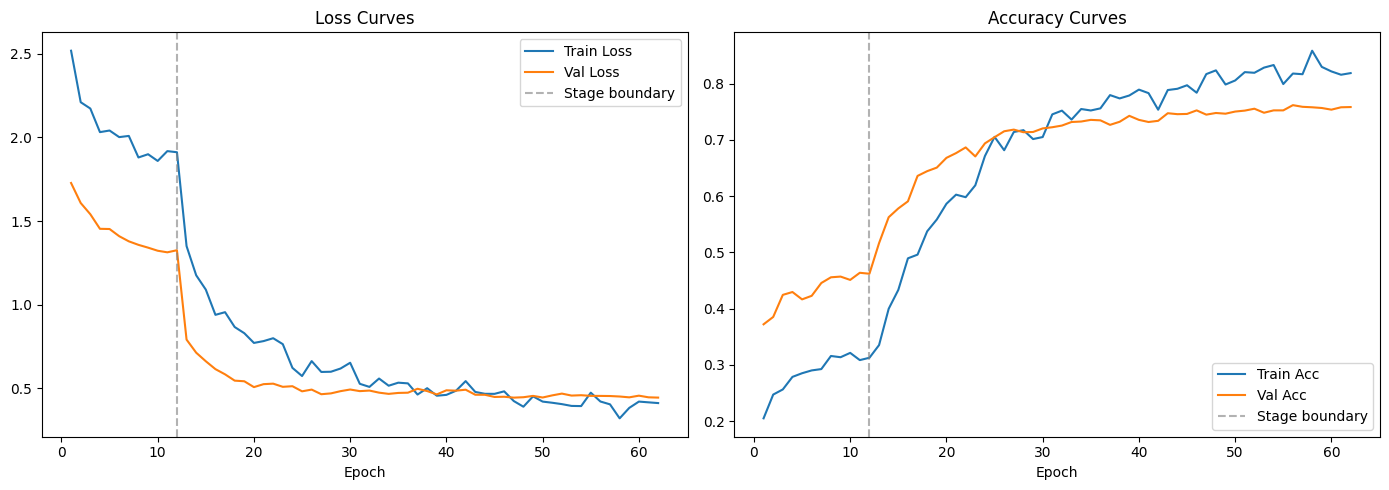

In [20]:
def plot_history(*trainers):
    all_history = {k: [] for k in ['train_loss', 'val_loss', 'train_acc', 'val_acc']}
    for t in trainers:
        for k in all_history:
            all_history[k].extend(t.history[k])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    epochs = range(1, len(all_history['train_loss']) + 1)

    axes[0].plot(epochs, all_history['train_loss'], label='Train Loss')
    axes[0].plot(epochs, all_history['val_loss'],   label='Val Loss')
    axes[0].set_title('Loss Curves'); axes[0].legend(); axes[0].set_xlabel('Epoch')

    axes[1].plot(epochs, all_history['train_acc'], label='Train Acc')
    axes[1].plot(epochs, all_history['val_acc'],   label='Val Acc')
    axes[1].set_title('Accuracy Curves'); axes[1].legend(); axes[1].set_xlabel('Epoch')

    # Stage 1 / Stage 2 boundary
    sep = len(trainer_s1.history['train_loss'])
    for ax in axes:
        ax.axvline(sep, color='gray', linestyle='--', alpha=0.6, label='Stage boundary')
        ax.legend()

    plt.tight_layout()
    plt.savefig(f'{CFG.OUTPUT_DIR}/training_curves.png', dpi=150)
    plt.show()

plot_history(trainer_s1, trainer_s2)

## 14. Evaluation

In [22]:
# Load best checkpoint
model.load_state_dict(torch.load(CFG.CHECKPOINT_PATH, map_location=DEVICE))
model.eval()
print('Best checkpoint loaded ✓')

def tta_predict(model, dataset_paths, dataset_labels, img_size, n_tta=5):
    """Returns (all_probs [N, C], all_labels [N]) using TTA."""
    tta_tf     = get_tta_transform(img_size)
    all_probs  = []
    all_labels = []

    for path, label in zip(dataset_paths, dataset_labels):
        img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
        aug_preds = []
        for _ in range(n_tta):
            t_img = tta_tf(image=img)['image'].unsqueeze(0).to(DEVICE)
            with torch.no_grad(), autocast(enabled=CFG.USE_AMP):
                logit = model(t_img)
            aug_preds.append(F.softmax(logit, dim=1).cpu().numpy())
        all_probs.append(np.mean(aug_preds, axis=0)[0])
        all_labels.append(label)

    return np.array(all_probs), np.array(all_labels)

print('Running TTA on validation set...')
val_probs, val_true = tta_predict(model, val_paths, val_labels,
                                   CFG.IMG_SIZE_STAGE2, n_tta=CFG.TTA_STEPS)
val_preds = val_probs.argmax(1)
print('TTA inference done ✓')

Best checkpoint loaded ✓
Running TTA on validation set...
TTA inference done ✓


In [23]:
class_correct = [0] * NUM_CLASSES
class_total   = [0] * NUM_CLASSES

for t, p in zip(val_true, val_preds):
    class_total[t] += 1
    if t == p:
        class_correct[t] += 1

print("\nClass-wise Accuracy:\n")
for i in range(NUM_CLASSES):
    acc = class_correct[i] / class_total[i] if class_total[i] > 0 else 0
    print(f"{CLASS_NAMES[i]:25s}: {acc:.4f}")


Class-wise Accuracy:

Acne                     : 0.6966
Basal Cell Carcinoma     : 0.8131
Benign tumors            : 0.3558
Bullous                  : 0.5517
Candidiasis              : 0.6757
Dermatofibroma           : 0.8462
DrugEruption             : 0.6098
Eczema                   : 0.5263
Hailey-Hailey Disease    : 0.6471
Herpes Simplex           : 0.8462
Impetigo                 : 0.8125
Infestations Bites       : 0.5823
Keratosis                : 0.5918
Larva Migrans            : 0.9412
Leprosy                  : 0.6234
Lichen Disorder          : 0.4545
Lupus Erythematosus      : 0.5000
Melanoma                 : 0.5802
Moles                    : 0.5000
Molluscum Contagiosum    : 0.9375
Nevus                    : 0.8667
Normal                   : 0.9900
Pityriasis Rosea         : 0.6000
Psoriasis                : 0.5036
Rosacea                  : 0.6316
Squamous cell carcinoma  : 0.4828
Sun Sunlight Damage      : 0.5319
Tinea                    : 0.6087
Vascular Tumors or Lesion

In [26]:
acc = accuracy_score(val_true, val_preds)
prec, rec, f1, _ = precision_recall_fscore_support(
    val_true, val_preds, average='weighted', zero_division=0)

print(f'\n{"─"*50}')

for k in CFG.TOP_K:
    topk = top_k_accuracy_score(val_true, val_probs, k=k)
    print(f'Top-{k} Acc  : {topk:.4f}')

print(f'Precision  : {prec:.4f}')
print(f'Recall     : {rec:.4f}')
print(f'F1-Score   : {f1:.4f}')



try:
    auc = roc_auc_score(val_true, val_probs, multi_class='ovr', average='macro')
    print(f'ROC-AUC    : {auc:.4f}')
except Exception as e:
    print(f'ROC-AUC    : N/A ({e})')
print(f'{"─"*50}')


──────────────────────────────────────────────────
Top-3 Acc  : 0.8624
Top-5 Acc  : 0.9228
Precision  : 0.6785
Recall     : 0.6456
F1-Score   : 0.6467
ROC-AUC    : N/A (Target scores need to be probabilities for multiclass roc_auc, i.e. they should sum up to 1.0 over classes)
──────────────────────────────────────────────────



Per-class metrics:
                    Class  Precision   Recall       F1  Support
               Vasculitis   0.388889 0.507246 0.440252       69
         Pityriasis Rosea   0.360000 0.600000 0.450000       15
      Sun Sunlight Damage   0.396825 0.531915 0.454545       47
       Infestations Bites   0.380165 0.582278 0.460000       79
            Benign tumors   0.763158 0.355828 0.485356      163
  Squamous cell carcinoma   0.500000 0.482759 0.491228       29
            Larva Migrans   0.333333 0.941176 0.492308       17
          Lichen Disorder   0.569620 0.454545 0.505618       99
      Lupus Erythematosus   0.517241 0.500000 0.508475       60
                    Tinea   0.515337 0.608696 0.558140      138
             DrugEruption   0.537634 0.609756 0.571429       82
                    Moles   0.675000 0.500000 0.574468       54
           Herpes Simplex   0.440000 0.846154 0.578947       13
                Psoriasis   0.686275 0.503597 0.580913      139
                 Imp

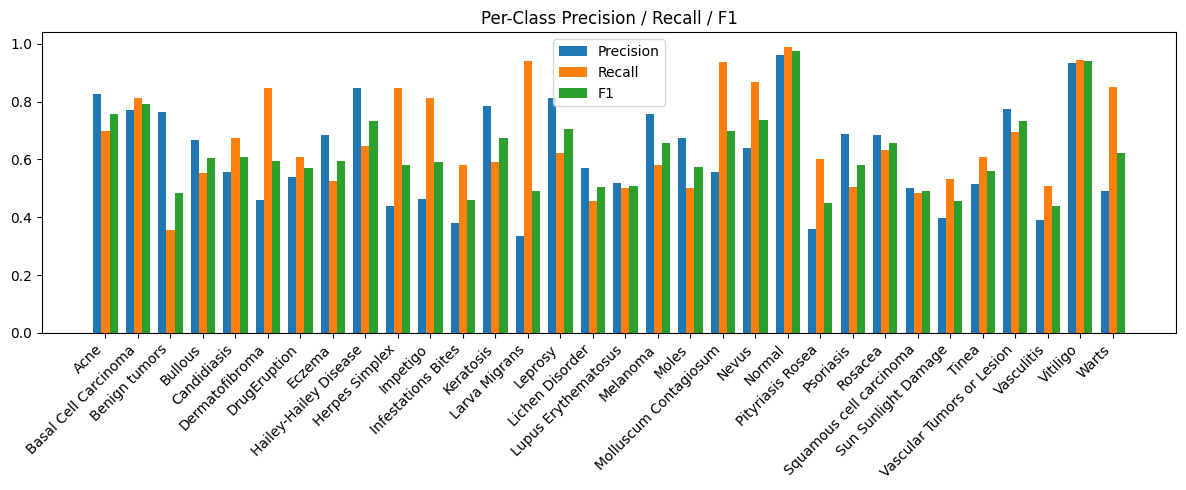

In [27]:
prec_pc, rec_pc, f1_pc, sup_pc = precision_recall_fscore_support(
    val_true, val_preds, average=None, zero_division=0)

df_metrics = pd.DataFrame({
    'Class'    : CLASS_NAMES,
    'Precision': prec_pc,
    'Recall'   : rec_pc,
    'F1'       : f1_pc,
    'Support'  : sup_pc.astype(int),
}).sort_values('F1')

print('\nPer-class metrics:')
print(df_metrics.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(NUM_CLASSES); w = 0.25
ax.bar(x - w, prec_pc, w, label='Precision')
ax.bar(x,      rec_pc,  w, label='Recall')
ax.bar(x + w,  f1_pc,   w, label='F1')
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
ax.set_title('Per-Class Precision / Recall / F1')
ax.legend(); plt.tight_layout()
plt.savefig(f'{CFG.OUTPUT_DIR}/per_class_metrics.png', dpi=150)
plt.show()

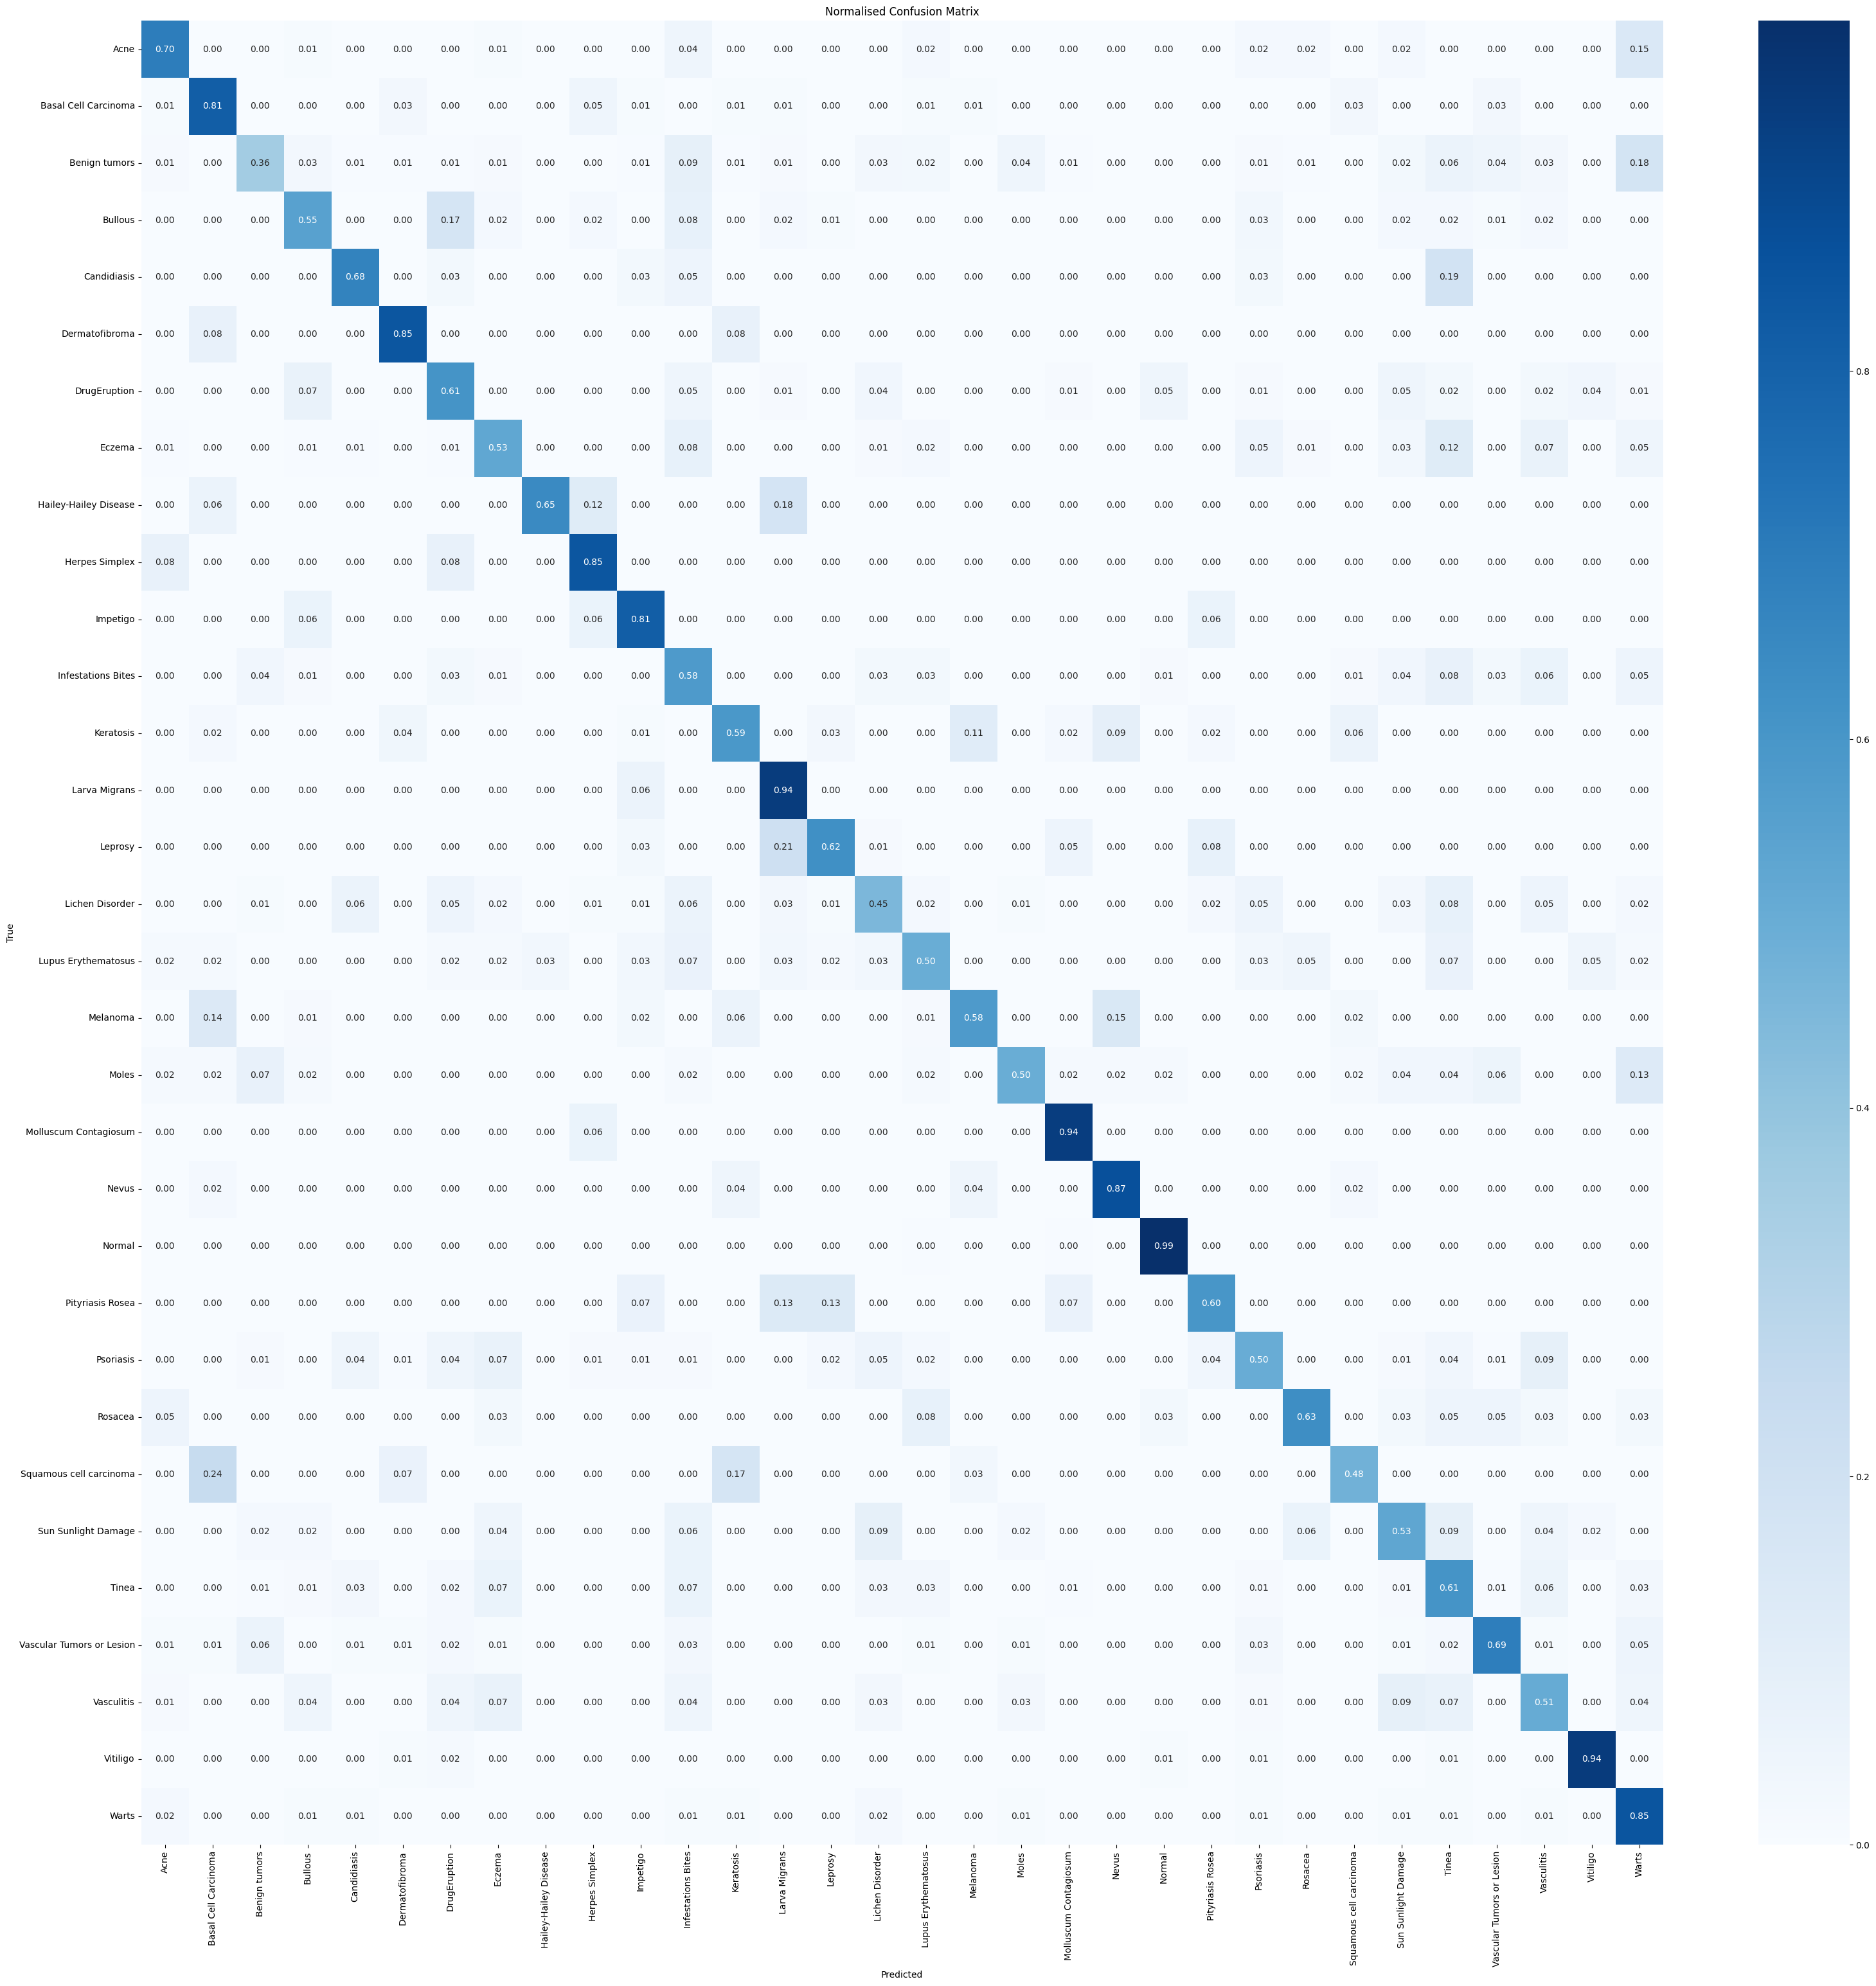

In [28]:
cm   = confusion_matrix(val_true, val_preds)
cm_n = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(max(8, NUM_CLASSES), max(6, NUM_CLASSES - 1)))
sns.heatmap(cm_n, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Normalised Confusion Matrix')
plt.tight_layout()
plt.savefig(f'{CFG.OUTPUT_DIR}/confusion_matrix.png', dpi=150)
plt.show()

## 15. OOD Detection — Monte Carlo Dropout

In [29]:
def enable_dropout(model):
    """Set Dropout layers to train mode for MC Dropout."""
    for m in model.modules():
        if isinstance(m, nn.Dropout):
            m.train()

def mc_dropout_predict(model, img_tensor: torch.Tensor, n_passes: int = 20) -> dict:
    """n stochastic forward passes with Dropout active."""
    model.eval()
    enable_dropout(model)

    all_probs = []
    with torch.no_grad(), autocast(enabled=CFG.USE_AMP):
        for _ in range(n_passes):
            logits = model(img_tensor)
            probs  = F.softmax(logits, dim=1)
            all_probs.append(probs.cpu().numpy())

    all_probs  = np.array(all_probs)
    mean_prob  = all_probs.mean(axis=0)
    var_prob   = all_probs.var(axis=0).mean(1)

    pred_class = mean_prob.argmax(1)
    confidence = mean_prob.max(1)
    uncertain  = ((confidence < CFG.OOD_CONF_THRESHOLD) |
                  (var_prob   > CFG.OOD_VAR_THRESHOLD))

    return {'mean_prob': mean_prob, 'variance': var_prob,
            'pred_class': pred_class, 'confidence': confidence,
            'uncertain': uncertain}

print('Running MC Dropout OOD detection on validation set...')
val_tf = get_val_transforms(CFG.IMG_SIZE_STAGE2)

mc_preds, mc_conf, mc_var, mc_flag = [], [], [], []

# val_true is already np.array from tta_predict
for path, label in zip(val_paths[:500], val_true[:500]):
    img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
    t   = val_tf(image=img)['image'].unsqueeze(0).to(DEVICE)
    res = mc_dropout_predict(model, t, n_passes=CFG.MC_DROPOUT_PASSES)
    mc_preds.append(res['pred_class'][0])
    mc_conf.append(res['confidence'][0])
    mc_var.append(res['variance'][0])
    mc_flag.append(res['uncertain'][0])

mc_preds = np.array(mc_preds)
mc_conf  = np.array(mc_conf)
mc_var   = np.array(mc_var)
mc_flag  = np.array(mc_flag)

n_uncertain = mc_flag.sum()
ood_acc = accuracy_score(val_true[:500][~mc_flag], mc_preds[~mc_flag])
print(f'\nMC Dropout results (N=500 samples):')
print(f'  Uncertain predictions : {n_uncertain} ({n_uncertain/5:.1f}%)')
print(f'  Accuracy on confident : {ood_acc:.4f}')

Running MC Dropout OOD detection on validation set...

MC Dropout results (N=500 samples):
  Uncertain predictions : 68 (13.6%)
  Accuracy on confident : 0.6898


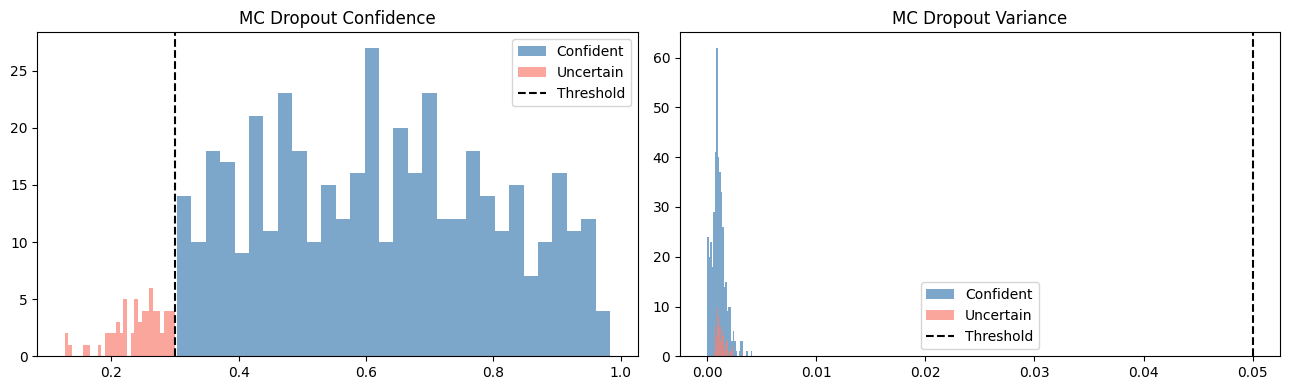

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(mc_conf[~mc_flag], bins=30, alpha=0.7, label='Confident', color='steelblue')
axes[0].hist(mc_conf[mc_flag],  bins=30, alpha=0.7, label='Uncertain',  color='salmon')
axes[0].axvline(CFG.OOD_CONF_THRESHOLD, color='black', ls='--', label='Threshold')
axes[0].set_title('MC Dropout Confidence'); axes[0].legend()

axes[1].hist(mc_var[~mc_flag], bins=30, alpha=0.7, label='Confident', color='steelblue')
axes[1].hist(mc_var[mc_flag],  bins=30, alpha=0.7, label='Uncertain',  color='salmon')
axes[1].axvline(CFG.OOD_VAR_THRESHOLD, color='black', ls='--', label='Threshold')
axes[1].set_title('MC Dropout Variance'); axes[1].legend()

plt.tight_layout()
plt.savefig(f'{CFG.OUTPUT_DIR}/ood_distributions.png', dpi=150)
plt.show()

## 17. Robustness Under Corruptions

  Original            : 0.6500
  Heavy Blur          : 0.5350
  High Noise          : 0.4600
  Low Brightness      : 0.3550
  JPEG Artefacts      : 0.6550


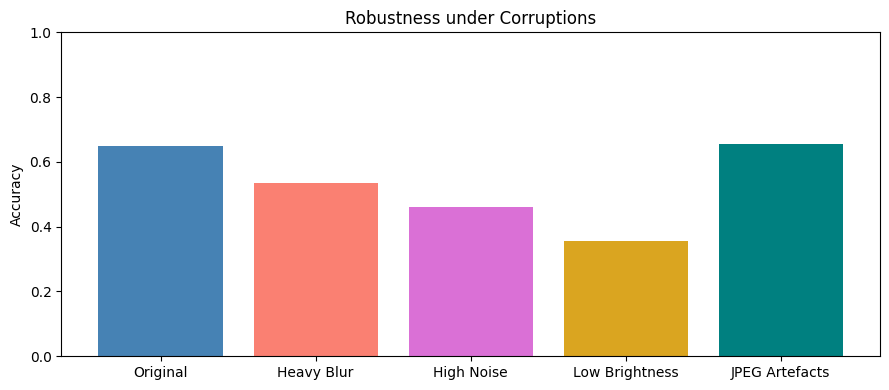

In [32]:
CORRUPTION_TRANSFORMS = {
    'Original'      : get_val_transforms(CFG.IMG_SIZE_STAGE2),
    'Heavy Blur'    : A.Compose([
        A.Resize(CFG.IMG_SIZE_STAGE2, CFG.IMG_SIZE_STAGE2),
        A.GaussianBlur(blur_limit=(15, 21)),
        A.Normalize(IMAGENET_MEAN, IMAGENET_STD), ToTensorV2()]),
    'High Noise'    : A.Compose([
        A.Resize(CFG.IMG_SIZE_STAGE2, CFG.IMG_SIZE_STAGE2),
        A.GaussNoise(var_limit=(80, 150)),
        A.Normalize(IMAGENET_MEAN, IMAGENET_STD), ToTensorV2()]),
    'Low Brightness': A.Compose([
        A.Resize(CFG.IMG_SIZE_STAGE2, CFG.IMG_SIZE_STAGE2),
        A.RandomBrightnessContrast(brightness_limit=(-0.5, -0.4), contrast_limit=0.0, p=1.0),
        A.Normalize(IMAGENET_MEAN, IMAGENET_STD), ToTensorV2()]),
    'JPEG Artefacts': A.Compose([
        A.Resize(CFG.IMG_SIZE_STAGE2, CFG.IMG_SIZE_STAGE2),
        A.ImageCompression(quality_lower=10, quality_upper=20, p=1.0),
        A.Normalize(IMAGENET_MEAN, IMAGENET_STD), ToTensorV2()]),
}

model.eval()
sample_paths  = val_paths[:200]
sample_labels = val_true[:200]
robustness_results = {}

for name, tf in CORRUPTION_TRANSFORMS.items():
    preds = []
    for path in sample_paths:
        img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
        t   = tf(image=img)['image'].unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            preds.append(model(t).argmax(1).item())
    acc = accuracy_score(sample_labels, preds)
    robustness_results[name] = acc
    print(f'  {name:20s}: {acc:.4f}')

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(robustness_results.keys(), robustness_results.values(),
        color=['steelblue', 'salmon', 'orchid', 'goldenrod', 'teal'])
ax.set_ylabel('Accuracy'); ax.set_title('Robustness under Corruptions')
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(f'{CFG.OUTPUT_DIR}/robustness_eval.png', dpi=150)
plt.show()

## 18. Production Inference Function

In [33]:
def predict_image(image_path: str, model, class_names,
                   img_size: int = CFG.IMG_SIZE_STAGE2,
                   use_tta: bool = True, n_tta: int = CFG.TTA_STEPS,
                   use_mc_dropout: bool = True,
                   mc_passes: int = CFG.MC_DROPOUT_PASSES) -> dict:
    """
    Production inference for a single image.
    Returns: predicted_class, confidence, top3, mc_variance, uncertain flag.
    """
    img = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)

    if use_tta:
        tf = get_tta_transform(img_size)
        probs_list = []
        with torch.no_grad(), autocast(enabled=CFG.USE_AMP):
            for _ in range(n_tta):
                t = tf(image=img)['image'].unsqueeze(0).to(DEVICE)
                p = F.softmax(model(t), 1).cpu().numpy()[0]
                probs_list.append(p)
        mean_probs = np.mean(probs_list, axis=0)
    else:
        tf = get_val_transforms(img_size)
        t  = tf(image=img)['image'].unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            mean_probs = F.softmax(model(t), 1).cpu().numpy()[0]

    mc_var, uncertain = 0.0, False
    if use_mc_dropout:
        tf  = get_val_transforms(img_size)
        t   = tf(image=img)['image'].unsqueeze(0).to(DEVICE)
        res = mc_dropout_predict(model, t, n_passes=mc_passes)
        mc_var    = float(res['variance'][0])
        uncertain = bool(res['uncertain'][0])

    confidence = float(mean_probs.max())
    if confidence < CFG.OOD_CONF_THRESHOLD:
        uncertain = True

    pred_idx = int(mean_probs.argmax())
    top3_idx = mean_probs.argsort()[-3:][::-1]

    return {
        'predicted_class': class_names[pred_idx],
        'confidence'     : round(confidence, 4),
        'top3_classes'   : [class_names[i] for i in top3_idx],
        'top3_probs'     : [round(float(mean_probs[i]), 4) for i in top3_idx],
        'mc_variance'    : round(mc_var, 6),
        'uncertain'      : uncertain,
        'status'         : 'UNCERTAIN ⚠️' if uncertain else 'CONFIDENT ✓',
    }

print('\nSample inference results:\n')
for path, true_lbl in zip(val_paths[:5], val_true[:5]):
    result = predict_image(path, model, CLASS_NAMES)
    print(f'True: {CLASS_NAMES[true_lbl]:25s} | '
          f'Pred: {result["predicted_class"]:25s} | '
          f'Conf: {result["confidence"]:.4f} | {result["status"]}')


Sample inference results:

True: Moles                     | Pred: Infestations Bites        | Conf: 0.6814 | CONFIDENT ✓
True: Tinea                     | Pred: Tinea                     | Conf: 0.5276 | CONFIDENT ✓
True: Benign tumors             | Pred: Warts                     | Conf: 0.5367 | CONFIDENT ✓
True: Benign tumors             | Pred: Lichen Disorder           | Conf: 0.2514 | UNCERTAIN ⚠️
True: Candidiasis               | Pred: Candidiasis               | Conf: 0.6736 | CONFIDENT ✓


## 19. Save Artefacts & Summary

In [35]:
with open(f'{CFG.OUTPUT_DIR}/class_names.json', 'w') as f:
    json.dump({i: n for i, n in enumerate(CLASS_NAMES)}, f, indent=2)

summary = {
    'accuracy'          : round(topk,  4),
    'weighted_precision': round(prec, 4),
    'weighted_recall'   : round(rec,  4),
    'weighted_f1'       : round(f1,   4),
    'robustness'        : {k: round(v, 4) for k, v in robustness_results.items()},
    'ood_uncertain_pct' : round(100 * n_uncertain / 500, 2),
    'ood_confident_acc' : round(ood_acc, 4),
}
with open(f'{CFG.OUTPUT_DIR}/summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print('\n🏁  Training & Evaluation Complete!')
print(json.dumps(summary, indent=2))
print(f'\nAll outputs saved to: {CFG.OUTPUT_DIR}')


🏁  Training & Evaluation Complete!
{
  "accuracy": 0.9228,
  "weighted_precision": 0.6785,
  "weighted_recall": 0.6456,
  "weighted_f1": 0.6467,
  "robustness": {
    "Original": 0.65,
    "Heavy Blur": 0.535,
    "High Noise": 0.46,
    "Low Brightness": 0.355,
    "JPEG Artefacts": 0.655
  },
  "ood_uncertain_pct": 13.6,
  "ood_confident_acc": 0.6898
}

All outputs saved to: /kaggle/working/


In [37]:
from IPython.display import FileLink

FileLink('/kaggle/working/best_model.pth')

/kaggle/working/best_model.pth